In [1]:
import numpy as np
import pandas as pd
import warnings
import graphviz
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import  train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_score
import joblib
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score


In [ ]:
# new_1_people_df = pd.read_csv("/home/ikuku/UDGU_project/main/data/saved_data/df_WO_data_spliting_with_new_1_category.csv")

In [ ]:
class tree_family():
    def __init__(self, df):
        self.df = pd.read_csv(df)
    def split_df_X_Y(self, name_of_column):
        self.x = self.df.drop(name_of_column,axis=1)
        self.y = self.df[name_of_column]
    def split_train_test(self,test_size=0.3):
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(self.x, self.y, test_size=test_size,random_state=42)
    def DecisionTreeClassifier(self,max_depth=4, bool_save = True):
        

        print("DecisionTreeClassifier\n\n")
        clf = DecisionTreeClassifier(random_state = 42,max_depth = max_depth)
        clf.fit(self.x_train, self.y_train)
        prediction = clf.predict(self.x_test)
        tree_family.metrix(self,prediction, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/DecisionTreeClassifier_with_new_1_category_people.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")

    def RandomForestClassifier(self,n_estimators=200,max_depth = 4,bool_save = True):
        
        print("RandomForestClassifier\n\n")

        clf = RandomForestClassifier(n_estimators=n_estimators,random_state = 42,max_depth = max_depth)
        clf.fit(self.x_train, self.y_train)
        y_pred = clf.predict(self.x_test)
        tree_family.metrix(self,y_pred, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/RandomForestClassifier_with_new_1_category_people.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")

        
    def GradientBoostingClassifier(self, n_estimators=200, max_depth=3, bool_save = True):
        
        print("GradientBoostingClassifier\n\n")


        clf = GradientBoostingClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        # Создаем веса для каждой строки обучающей выборки
        # weights = y_train.iloc[:, 0].map({0: 1, 1: 6})


        clf.fit(self.x_train, self.y_train)
        y_pred = clf.predict(self.x_test)
        tree_family.metrix(self,y_pred, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/GradientBoostingClassifier_with_new_1_category_people.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")


    def metrix(self,prediction,clf):
        from sklearn.model_selection import cross_val_score
        accuracy_score(prediction, self.y_test)
        print(f"Accuracy:{accuracy_score(self.y_test, prediction):.3f}")
        print(f"Precision:{precision_score(self.y_test, prediction):.3f}")
        print(f"Recall:  {recall_score(self.y_test, prediction):.3f}")
        print(f"F1-score: {f1_score(self.y_test, prediction):.3f}")
        # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
        print("\nConfusion Matrix:\n", confusion_matrix(self.y_test, prediction))
        print("\nClassification Report:\n", classification_report(self.y_test, prediction))


        scores_f1 = cross_val_score(clf, self.x, self.y, cv=10, scoring='f1')

        print(f"F1-результаты по фолдам: {scores_f1}")
        print(f"Средний F1: {scores_f1.mean():.2f}")
        from sklearn import metrics
        fpr, tpr, _ = metrics.roc_curve(self.y_test,  prediction)

        # построение ROC кривой
        plt.plot(fpr, tpr)
        plt.ylabel('True Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.show()

        return

In [126]:
WO_data_spliting_with_new_1_category = tree_family(r"/home/ikuku/UDGU_project/main/data/saved_data/df_WO_data_spliting_with_new_1_category.csv")

DecisionTreeClassifier


Accuracy:0.979
Precision:0.960
Recall:  1.000
F1-score: 0.980

Confusion Matrix:
 [[23  1]
 [ 0 24]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.96      0.98        24
         1.0       0.96      1.00      0.98        24

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48

F1-результаты по фолдам: [1.         1.         1.         1.         1.         0.94117647
 1.         1.         0.94117647 1.        ]
Средний F1: 0.99


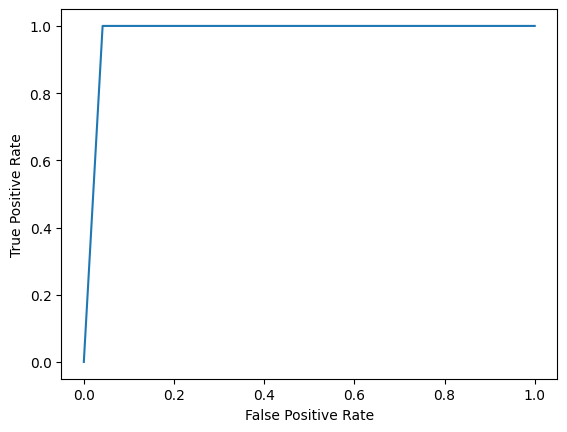

SAVE TURN OFF
RandomForestClassifier


Accuracy:1.000
Precision:1.000
Recall:  1.000
F1-score: 1.000

Confusion Matrix:
 [[24  0]
 [ 0 24]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        24
         1.0       1.00      1.00      1.00        24

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48

F1-результаты по фолдам: [1.         1.         1.         1.         1.         1.
 1.         1.         0.94117647 0.88888889]
Средний F1: 0.98


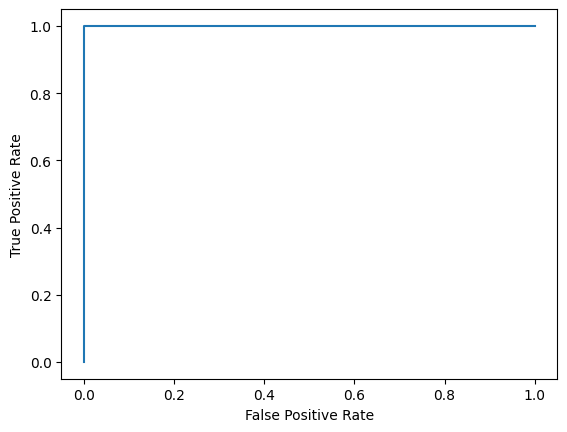

GradientBoostingClassifier


Accuracy:0.979
Precision:0.960
Recall:  1.000
F1-score: 0.980

Confusion Matrix:
 [[23  1]
 [ 0 24]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.96      0.98        24
         1.0       0.96      1.00      0.98        24

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48

F1-результаты по фолдам: [0.94117647 1.         1.         1.         1.         1.
 1.         1.         0.94117647 1.        ]
Средний F1: 0.99


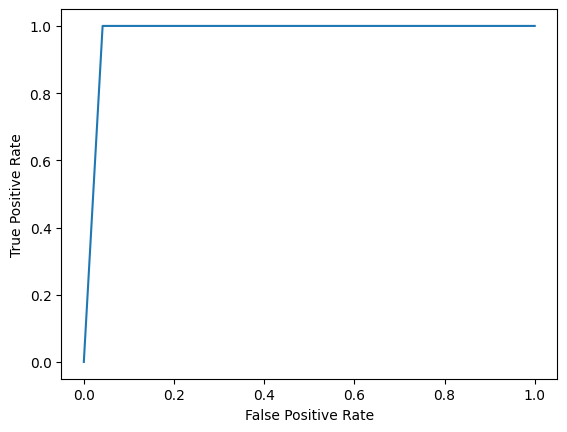

In [ ]:
WO_data_spliting_with_new_1_category.split_df_X_Y("здоров(1)\болен(0)")
WO_data_spliting_with_new_1_category.split_train_test()
WO_data_spliting_with_new_1_category.DecisionTreeClassifier()
WO_data_spliting_with_new_1_category.RandomForestClassifier()
WO_data_spliting_with_new_1_category.GradientBoostingClassifier()

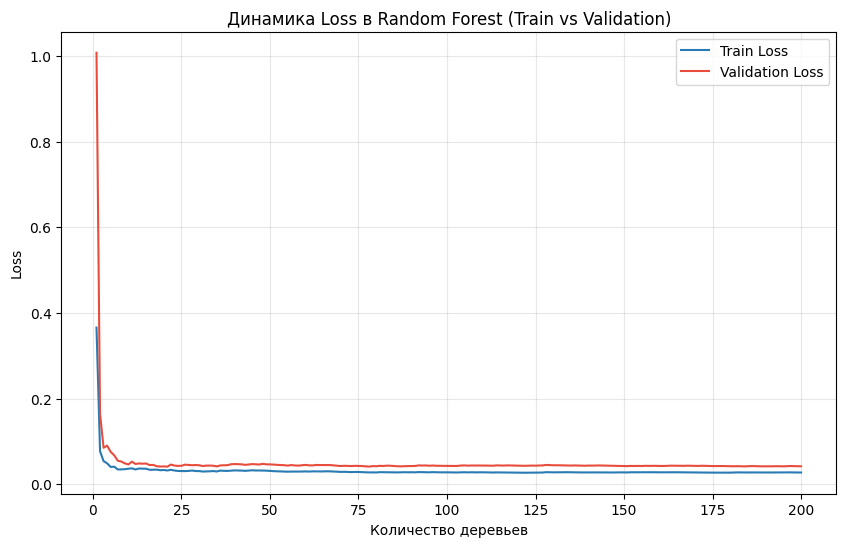

In [2]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
df = pd.read_csv(r"C:\Users\a.v.nasirov\Desktop\UDGU_project\data\saved_data\df_WO_data_spliting_with_new_1_category.csv")

x = df.drop("здоров(1)\болен(0)",axis=1)
y = df["здоров(1)\болен(0)"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=42)

# 1. Инициализация модели
# warm_start=True позволяет добавлять деревья, не обучая всё заново
clf = RandomForestClassifier(
max_depth = 4,
warm_start=True
)

train_losses = []
val_losses = []
tree_counts = range(1, 201) # Пройдем от 1 до 100 деревьев

for i in tree_counts:
    clf.set_params(n_estimators=i)
    clf.fit(x_train, y_train)
    
    # Предсказываем вероятности для расчета Logloss
    train_proba = clf.predict_proba(x_train)
    val_proba = clf.predict_proba(x_test)
    
    train_losses.append(log_loss(y_train, train_proba))
    val_losses.append(log_loss(y_test, val_proba))

# 2. Визуализация
plt.figure(figsize=(10, 6))
plt.plot(tree_counts, train_losses, label='Train Loss', color="#287bb3")
plt.plot(tree_counts, val_losses, label='Validation Loss', color='#e74c3c')

plt.title('Динамика Loss в Random Forest (Train vs Validation)')
plt.xlabel('Количество деревьев')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()